# Limpieza y Tratamiento de Datos Spotify

* Objetivo

El presente notebook tiene como objetivo realizar una etapa de limpieza, análisis y tratamiento de datos sobre el conjunto de datos de Spotify.

A partir del dataset crudo, se ejecutan diferentes procedimientos orientados a mejorar la calidad de los datos y preparar el conjunto de información para las etapas posteriores de ingeniería de características y modelado predictivo.

Las principales tareas realizadas son:

* Carga y preparación del dataset.

* Eliminación de variables no relevantes.
* Detección de valores atípicos (outliers).
* Comparación de métodos de detección de outliers.
* Identificación y tratamiento de valores nulos.
* Identificación y eliminación de registros duplicados.
* Análisis estadístico posterior a la limpieza.
* Aplicación de winsorización mediante el método IQR.
* Evaluación de la variable objetivo popularity.
* Visualización de las distribuciones numéricas.
* Exportación del dataset tratado.

---

# Importación y configuración del entorno

Se importan las bibliotecas necesarias para la manipulación de datos, generación de visualizaciones y configuración de las rutas del proyecto.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
"""
En caso de que Python no encuentre en la ruta los otros directorios,
ejecutar esta configuración
"""

sys.path.append(os.path.abspath(".."))

"""
Al ser utilidades locales del repositorio
se deben realizar la importación luego
del sys.path()
"""
from utils import eda_utils, vis_descriptiva

---

# Carga del dataset

In [2]:
data = pd.read_csv("../dataset/spotify_crudo.csv")

df = data.copy()

El archivo `spotify_crudo.csv` corresponde a la versión inicial de los datos, sobre la cual se aplicarán las distintas etapas de limpieza y transformación.

Se utiliza una copia mediante `data.copy()` para trabajar sobre un DataFrame independiente.

---

# Inspección inicial

Antes de realizar modificaciones sobre los datos, se efectúa una inspección preliminar del conjunto de datos.

## Primeros registros

El método `head()` permite visualizar los primeros registros del dataset y obtener una primera aproximación a la estructura y contenido de las variables.

In [3]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Información estructural

La función `info()` permite identificar:

* Cantidad de registros.
* Cantidad de variables.
* Tipos de datos.
* Valores no nulos.
* Uso aproximado de memoria.

Esta información es relevante para detectar posibles inconsistencias en los tipos de datos y determinar qué variables requieren tratamiento.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

---

# Eliminación de variables no relevantes

Se eliminan determinadas variables que no serán utilizadas en las etapas posteriores:

In [5]:
df = df.drop(columns=["Unnamed: 0", "track_id", "time_signature"])

Las variables eliminadas corresponden a:

`Unnamed: 0`

Corresponde a una columna de índice generada durante la manipulación o exportación previa del dataset. No representa una característica musical relevante y, por lo tanto, se elimina.

`track_id`

Corresponde a un identificador único de la pista. Debido a que funciona principalmente como identificador y no como una característica predictiva con significado numérico directo, se excluye del conjunto de variables utilizadas para el análisis.

`time_signature`

Esta variable representa la métrica o compás de la canción. En este proceso se decidió eliminar puesto que no aporta valor estadístico al caso al solo aportar un valor único.

---

# Detección de valores atípicos

Una parte importante del proceso de limpieza corresponde a la identificación de valores atípicos (outliers).

Para esto se utiliza la estrategias implementada en `eda_utils`:

In [ ]:
outliers_iqr = eda_utils.detectar_outliers_iqr(df)

Se considera el método:

* Método del rango intercuartílico (IQR).

Puesto que en la fase de análisis exploratorio se logró identificar que las variables de este caso no siguen una distribución normal, por lo qué IQR es más robusta para medir outliers.

In [8]:
print("***Detección de outliers con método IQR***", end="\n" + ("-"*40) + "\n")

total_outliers_iqr = 0

outliers_iqr = eda_utils.detectar_outliers_iqr(df)
for col, info in outliers_iqr.items():
    total_outliers_iqr += info["cantidad_outliers"]

    print(f"Columna: {col}")
    print(f"Asimetría (skew): {info['skew']:.3f}")
    print(f"Cantidad de outliers: {info['cantidad_outliers']}")
    print(f"Límite inferior: {info['limite_inferior']:.3f}")
    print(f"Límite superior: {info['limite_superior']:.3f}")
    print("-"*40)

print(f"TOTAL DE OUTLIERS IDENTIFICADOS: {total_outliers_iqr}")

***Detección de outliers con método IQR***
----------------------------------------
Columna: popularity
Asimetría (skew): 0.046
Cantidad de outliers: 2
Límite inferior: -32.500
Límite superior: 99.500
----------------------------------------
Columna: duration_ms
Asimetría (skew): 11.195
Cantidad de outliers: 5617
Límite inferior: 42906.000
Límite superior: 392666.000
----------------------------------------
Columna: danceability
Asimetría (skew): -0.399
Cantidad de outliers: 620
Límite inferior: 0.098
Límite superior: 1.053
----------------------------------------
Columna: energy
Asimetría (skew): -0.597
Cantidad de outliers: 0
Límite inferior: -0.101
Límite superior: 1.427
----------------------------------------
Columna: key
Asimetría (skew): -0.009
Cantidad de outliers: 0
Límite inferior: -7.000
Límite superior: 17.000
----------------------------------------
Columna: loudness
Asimetría (skew): -2.007
Cantidad de outliers: 6173
Límite inferior: -17.528
Límite superior: 2.512
-------

---

# Tratamiento de valores nulos

Se verifica la cantidad de valores ausentes mediante:

In [9]:
df.isna().sum()

artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
track_genre         0
dtype: int64

In [10]:
df = df.dropna()

---

# Identificación y tratamiento de duplicados

Se determina inicialmente la cantidad de registros duplicados:

In [11]:
print(df.duplicated().sum())

577


In [12]:
duplicados = df[df.duplicated(keep=False)]

El parámetro `keep=False` permite identificar todas las apariciones de un registro duplicado, en lugar de marcar únicamente las ocurrencias posteriores a la primera.

In [13]:
duplicados

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_genre
1874,Buena Onda Reggae Club,Disco 2,Song for Rollins,16,219346,False,0.841,0.577,0,-7.544,1,0.0438,0.238000,0.860000,0.0571,0.843,90.522,afrobeat
1925,Buena Onda Reggae Club,Disco 2,Song for Rollins,16,219346,False,0.841,0.577,0,-7.544,1,0.0438,0.238000,0.860000,0.0571,0.843,90.522,afrobeat
2044,The Killers;Ryan Pardey,Alternative Christmas 2022,Don't Shoot Me Santa,0,245106,False,0.588,0.847,8,-4.164,1,0.0705,0.060100,0.000000,0.3070,0.662,120.041,alt-rock
2046,The Killers;Ryan Pardey,Alternative Christmas 2022,Don't Shoot Me Santa,0,245106,False,0.588,0.847,8,-4.164,1,0.0705,0.060100,0.000000,0.3070,0.662,120.041,alt-rock
2082,The Smashing Pumpkins,Alternative Christmas 2022,Christmastime,0,196723,False,0.165,0.434,0,-8.163,1,0.0288,0.316000,0.171000,0.2130,0.186,77.983,alt-rock
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112968,Acil Servis,Küçük Adam,Bebek,38,319933,False,0.486,0.485,5,-12.391,0,0.0331,0.004460,0.000017,0.3690,0.353,120.095,turkish
113295,Matt Redman,Sing Like Never Before: The Essential Collection,Our God - New Recording,34,265373,False,0.487,0.895,11,-5.061,1,0.0413,0.000183,0.000000,0.3590,0.384,105.021,world-music
113345,Matt Redman,Sing Like Never Before: The Essential Collection,Our God - New Recording,34,265373,False,0.487,0.895,11,-5.061,1,0.0413,0.000183,0.000000,0.3590,0.384,105.021,world-music
113881,Bryan & Katie Torwalt,I've Got Good News (Live) [Deluxe],Good News - Live,23,266632,False,0.473,0.474,6,-9.175,1,0.0558,0.395000,0.000000,0.1630,0.251,140.746,world-music


In [14]:
df = df.drop_duplicates()

Este procedimiento permite evitar que observaciones repetidas tengan una influencia desproporcionada sobre las estadísticas descriptivas y los modelos posteriores.

---

# Visualización de outliers antes de la winsorización

Después del tratamiento de valores nulos y duplicados, se vuelve a ejecutar la detección de outliers.

Posteriormente, se genera una representación gráfica de la cantidad de outliers detectados por variable:

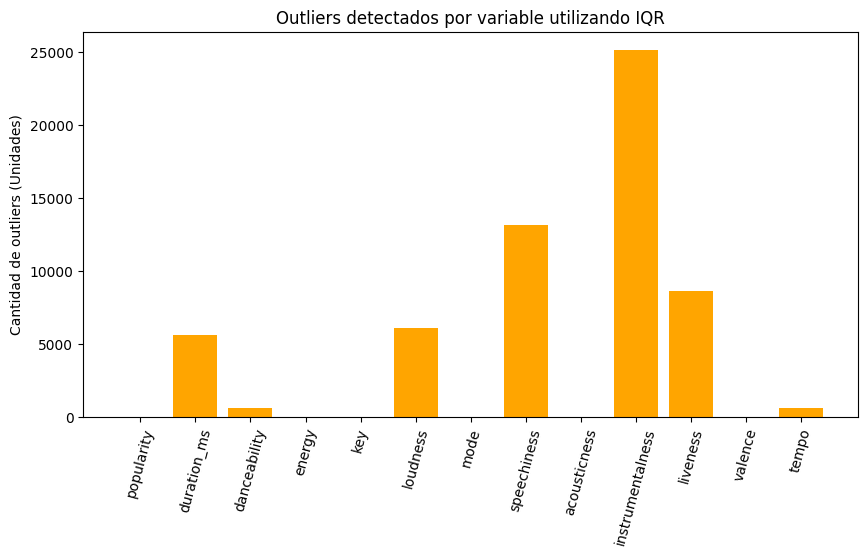

In [15]:
resultados = eda_utils.detectar_outliers_iqr(df)

outliers = {
    col: datos['cantidad_outliers']
    for col, datos in resultados.items()
}

plt.figure(figsize=(10,5))

plt.bar(
    outliers.keys(),
    outliers.values(),
        color = "orange"
)

plt.xticks(rotation=75)

plt.ylabel("Cantidad de outliers (Unidades)")
plt.title("Outliers detectados por variable utilizando IQR")

plt.show()

Esta visualización permite comparar rápidamente la cantidad de observaciones atípicas presentes en cada variable numérica.

La representación facilita la identificación de variables que requieren una atención especial durante el tratamiento de valores extremos.

In [16]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,113422.000000,1.134220e+05,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000
mean,33.359674,2.281011e+05,0.567113,0.642174,5.309332,-8.242913,0.637681,0.084697,0.314075,0.155802,0.213610,0.474239,122.176181
std,22.269626,1.064508e+05,0.173402,0.251031,3.559767,5.011931,0.480673,0.105803,0.331943,0.309314,0.190481,0.259239,29.972104
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.741700e+05,0.456000,0.473000,2.000000,-9.998000,0.000000,0.035900,0.016800,0.000000,0.098000,0.260000,99.299000
50%,35.000000,2.130160e+05,0.580000,0.685000,5.000000,-6.996000,1.000000,0.048900,0.168000,0.000041,0.132000,0.464000,122.019000
75%,50.000000,2.616000e+05,0.695000,0.854000,8.000000,-5.001000,1.000000,0.084575,0.596000,0.048700,0.273000,0.683000,140.073000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000


---

# Winsorización de valores atípicos

Para tratar los valores extremos restantes se aplica winsorización mediante el método IQR:

La winsorización consiste en limitar los valores extremos, reemplazándolos por los valores correspondientes a los límites establecidos.

A diferencia de eliminar observaciones, esta estrategia conserva la cantidad de registros del dataset y reduce la influencia de valores extremos.

En términos conceptuales:
<div align="center">

**Valor inferior extremo**  
↓  
**Límite inferior IQR**

<br>

**Valor superior extremo**  
↓  
**Límite superior IQR**

</div>
De esta manera, las observaciones no son eliminadas, sino que sus valores son restringidos al rango considerado aceptable según el criterio utilizado.

In [24]:
df_wins = eda_utils.winsorizar_iqr(df)

df_wins.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000,113422.000000
mean,33.359666,222615.009601,0.567327,0.642174,5.309332,-7.928039,0.637681,0.067221,0.314075,0.030741,0.196611,0.474239,122.210463
std,22.269600,73091.061378,0.172775,0.251031,3.559767,3.997161,0.480673,0.042555,0.331943,0.050686,0.140762,0.259239,29.735829
min,0.000000,43025.000000,0.097500,0.000000,0.000000,-17.493500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,38.138000
25%,17.000000,174170.000000,0.456000,0.473000,2.000000,-9.998000,0.000000,0.035900,0.016800,0.000000,0.098000,0.260000,99.299000
50%,35.000000,213016.000000,0.580000,0.685000,5.000000,-6.996000,1.000000,0.048900,0.168000,0.000041,0.132000,0.464000,122.019000
75%,50.000000,261600.000000,0.695000,0.854000,8.000000,-5.001000,1.000000,0.084575,0.596000,0.048700,0.273000,0.683000,140.073000
max,99.500000,392745.000000,0.985000,1.000000,11.000000,2.494500,1.000000,0.157587,0.996000,0.121750,0.535500,0.995000,201.234000


In [18]:
print("***Detección de outliers con método IQR***", end="\n" + ("-"*40) + "\n")

total_outliers_iqr = 0

outliers_iqr = eda_utils.detectar_outliers_iqr(df_wins)
for col, info in outliers_iqr.items():
    total_outliers_iqr += info["cantidad_outliers"]

    print(f"Columna: {col}")
    print(f"Asimetría (skew): {info['skew']:.3f}")
    print(f"Cantidad de outliers: {info['cantidad_outliers']}")
    print(f"Límite inferior: {info['limite_inferior']:.3f}")
    print(f"Límite superior: {info['limite_superior']:.3f}")
    print("-"*40)

print(f"TOTAL DE OUTLIERS IDENTIFICADOS: {total_outliers_iqr}")

***Detección de outliers con método IQR***
----------------------------------------
Columna: popularity
Asimetría (skew): 0.041
Cantidad de outliers: 0
Límite inferior: -32.500
Límite superior: 99.500
----------------------------------------
Columna: duration_ms
Asimetría (skew): 0.499
Cantidad de outliers: 0
Límite inferior: 43025.000
Límite superior: 392745.000
----------------------------------------
Columna: danceability
Asimetría (skew): -0.377
Cantidad de outliers: 0
Límite inferior: 0.098
Límite superior: 1.053
----------------------------------------
Columna: energy
Asimetría (skew): -0.599
Cantidad de outliers: 0
Límite inferior: -0.099
Límite superior: 1.425
----------------------------------------
Columna: key
Asimetría (skew): -0.009
Cantidad de outliers: 0
Límite inferior: -7.000
Límite superior: 17.000
----------------------------------------
Columna: loudness
Asimetría (skew): -0.869
Cantidad de outliers: 0
Límite inferior: -17.493
Límite superior: 2.494
----------------

---

# Evaluación de los valores atípicos después de la winsorización

Después de aplicar la winsorización, se vuelve a ejecutar la detección de outliers mediante IQR:

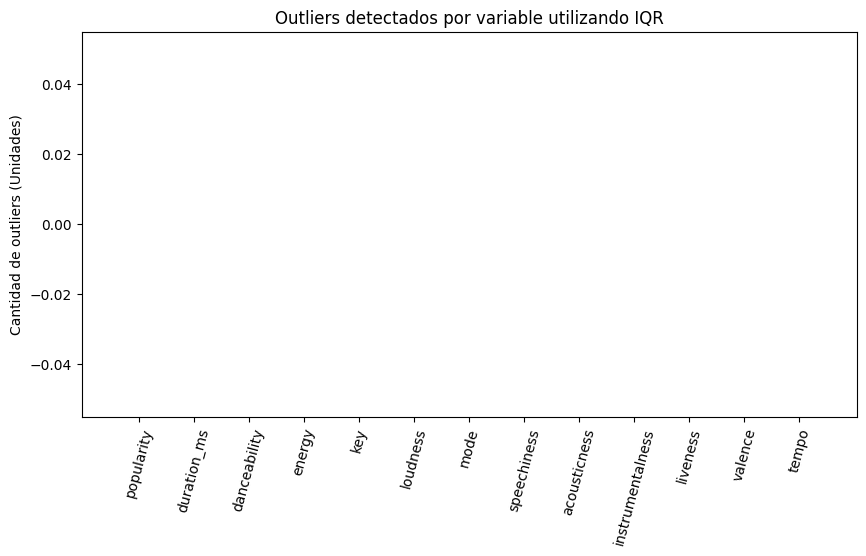

In [19]:
resultados = eda_utils.detectar_outliers_iqr(df_wins)

outliers = {
    col: datos['cantidad_outliers']
    for col, datos in resultados.items()
}

plt.figure(figsize=(10,5))

plt.bar(
    outliers.keys(),
    outliers.values(),
        color = "orange"
)

plt.xticks(rotation=75)

plt.ylabel("Cantidad de outliers (Unidades)")
plt.title("Outliers detectados por variable utilizando IQR")

plt.show()



Esto permite comprobar el efecto producido por el tratamiento.

---

# Análisis de la variable objetivo `popularity`

Una vez realizado el tratamiento de los datos, se analiza la distribución de la variable `popularity`.

Para ello, se utiliza un histograma acompañado de una estimación de densidad:

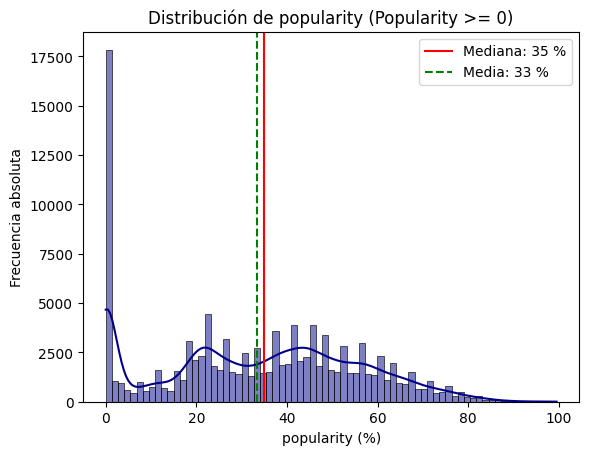

In [20]:
sns.histplot(
    data = df_wins,
    x = 'popularity',
    kde = True,
    color="darkblue"
)

plt.axvline(df_wins['popularity'].median(), label = f'Mediana: {df_wins['popularity'].median():.0f} %', color = 'red')
plt.axvline(df_wins['popularity'].mean(), label = f'Media: {df_wins['popularity'].mean():.0f} %', color = 'green', linestyle = '--')
plt.title('Distribución de popularity (Popularity >= 0)')
plt.xlabel('popularity (%)')
plt.ylabel('Frecuencia absoluta')
plt.legend()
plt.show()

---

# Análisis de `popularity` excluyendo valores iguales a cero

Posteriormente, se realiza un segundo análisis excluyendo las canciones cuya popularidad es igual a cero.

Esta separación permite analizar la distribución de popularidad de las canciones que presentan un valor positivo, evitando que una gran concentración de observaciones con `popularity = 0` pueda dificultar la interpretación de la distribución.

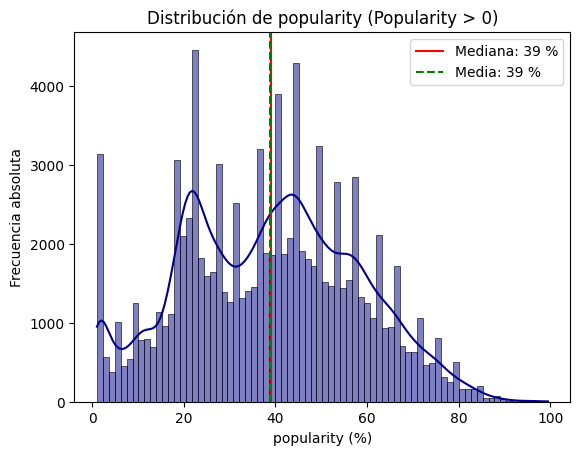

In [21]:
df_filtered = df_wins[df_wins['popularity'] > 0]

sns.histplot(
    data=df_filtered,
    x='popularity',
    kde=True,
    color="darkblue"
)

mediana = df_filtered['popularity'].median()
media = df_filtered['popularity'].mean()


plt.axvline(mediana, label=f"Mediana: {mediana:.0f} %", color='red')
plt.axvline(media, label=f"Media: {media:.0f} %", color='green', linestyle='--')

plt.title('Distribución de popularity (Popularity > 0)')
plt.xlabel('popularity (%)')
plt.ylabel('Frecuencia absoluta')
plt.legend()
plt.show()

---

# Visualización general de las distribuciones numéricas

Para complementar el análisis individual de popularity, se generan gráficos de distribución para las variables numéricas del dataset:

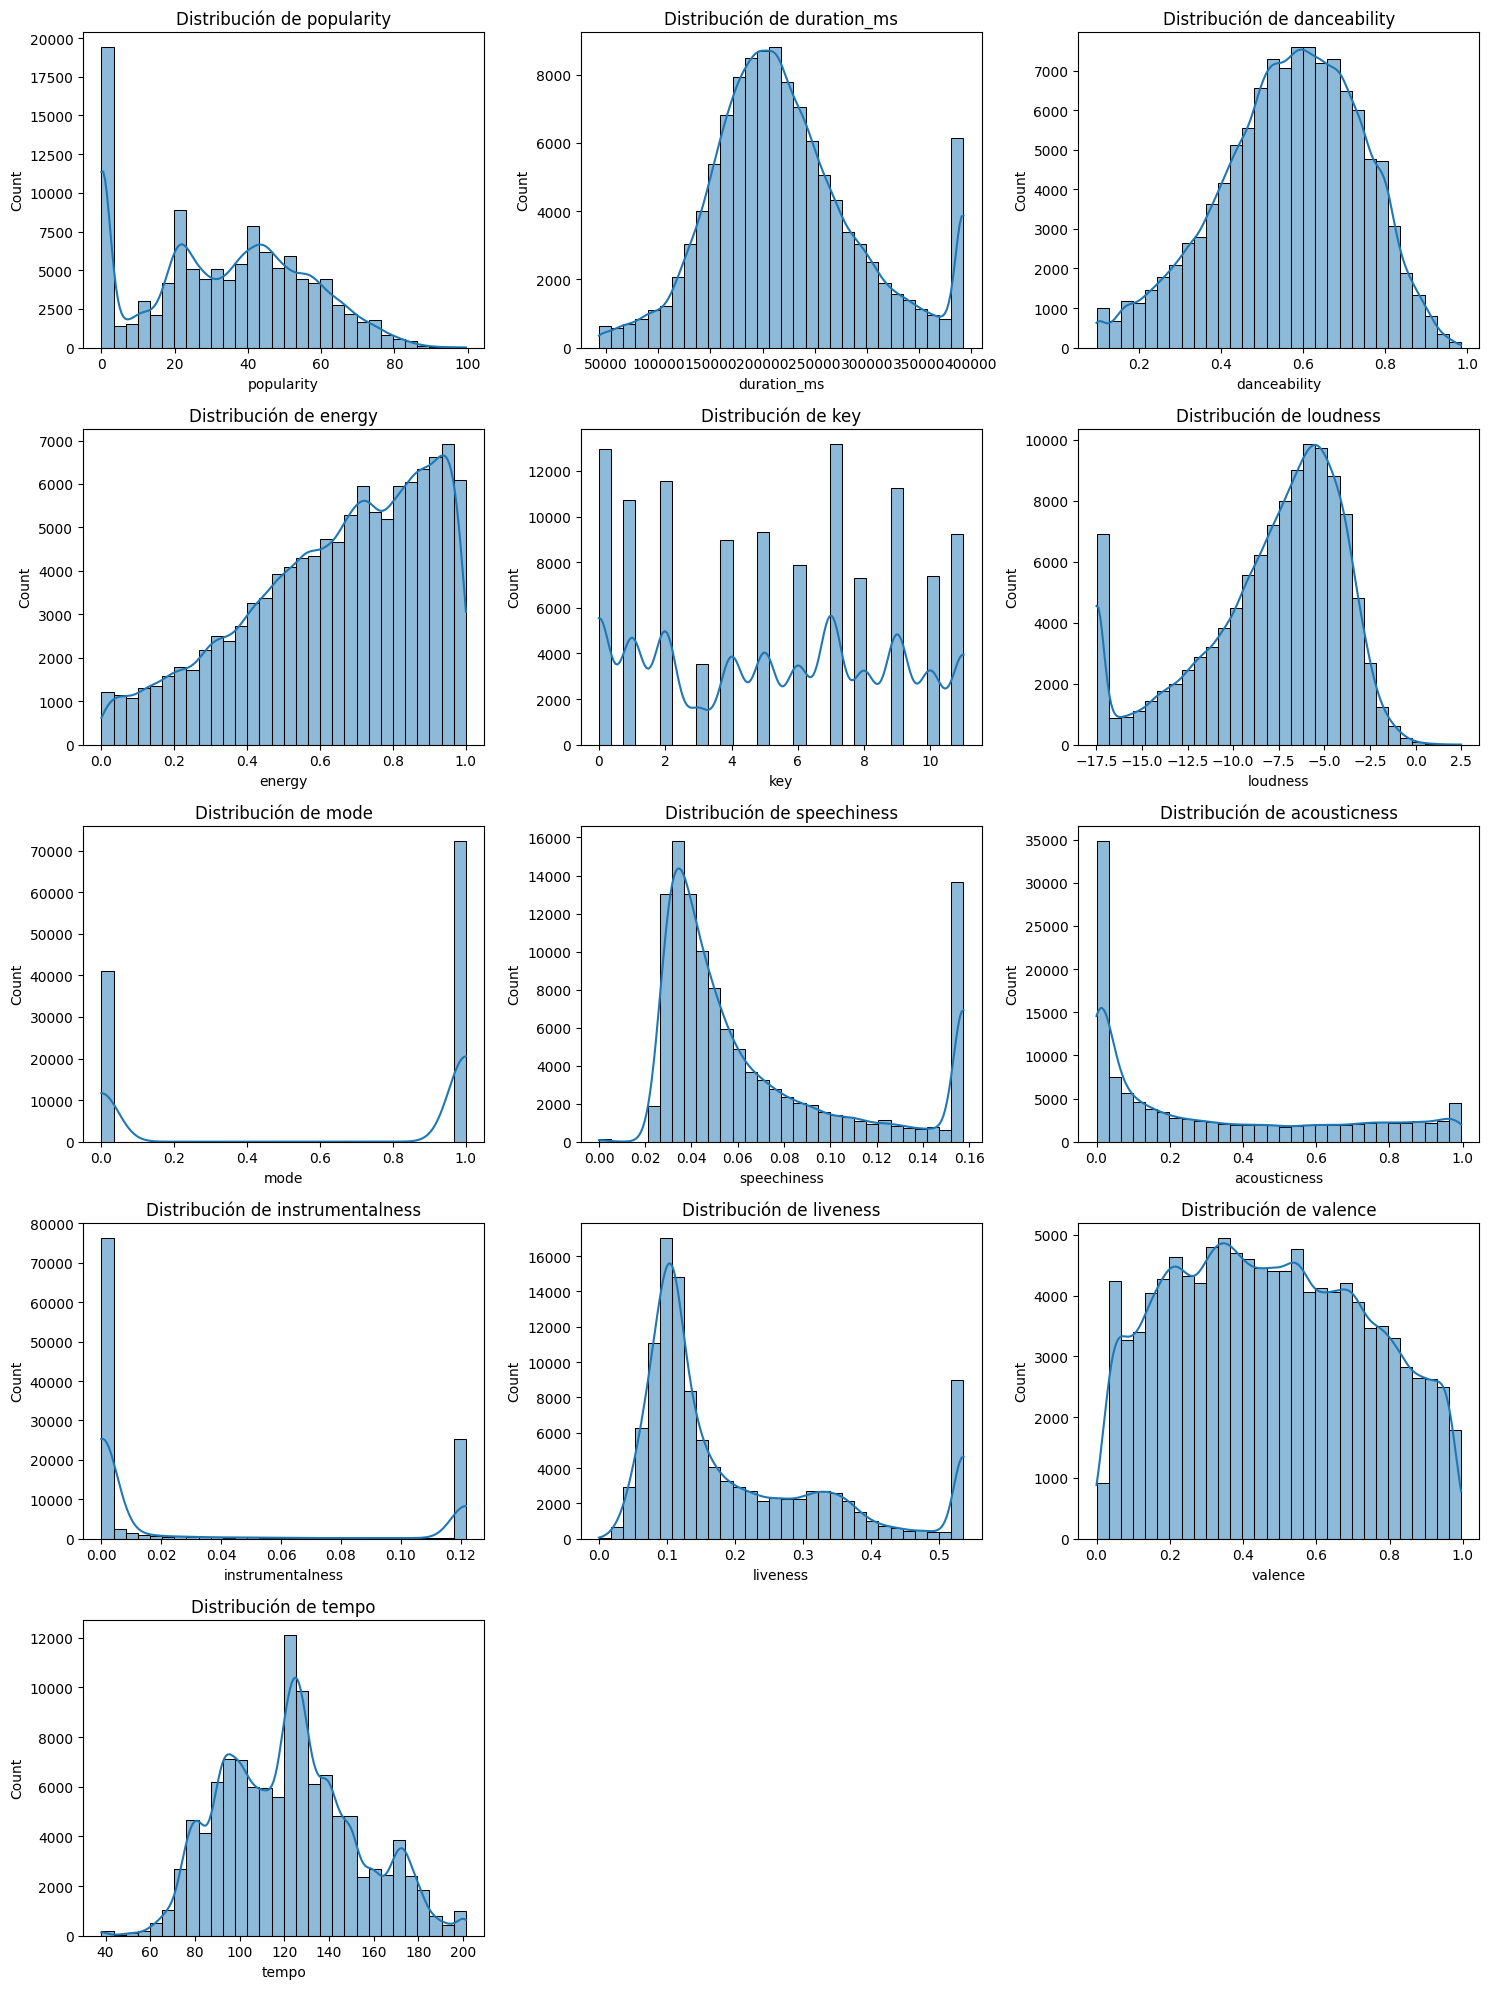

In [22]:
vis_descriptiva.graficar_distribuciones_numericas(df_wins)

---

# Exportación del dataset tratado

Una vez finalizado el proceso de limpieza y tratamiento de valores extremos, el dataset resultante se exporta en formato CSV:

In [23]:
df_wins.to_csv("../dataset/spotify_winsorizado.csv", index=False)